<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/analisis_datos/blob/main/01_Clasificación_Bayesiana/Caso_1.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

In [62]:
#########################################################
# Autor: Wilfrido Gómez Flores (Cinvestav)              #
# E-mail: wgomez@cinvestav.mx                           #
# Curso:   Análisis de datos                            #
# Tópico:  Clasificador de mínima distancia Euclidiana  #
#########################################################

Carga bibliotecas necesarias

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Carga el conjunto de datos Iris con 3 clases, 150 muestras y 4 variables

In [64]:
iris = load_iris()
df = pd.DataFrame(data=iris.data)
X = df.to_numpy() # Características
df = pd.DataFrame(data=iris.target)
Y = df.to_numpy()+1 # Etiquetas de clase: 1,2 3
d = X.shape[1] # Número de variables
c = np.unique(Y).size # Número de clases

Divide el conjunto de datos en 80\% para entrenamiento y 20\% para prueba

In [65]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

Normaliza el conjunto de datos con z-score:  $z = \frac{x-\mu}{\sigma}$

In [66]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Normaliza el conjunto de entrenamiento
X_test = scaler.transform(X_test) # Normaliza el conjunto de prueba usando los estadísticos del conjunto de entrenamiento

Entrenamiento del clasificador de mínima distancia Euclidiana: calcular el vector de medias para cada clase

In [67]:
mu = np.zeros((c, d)) # Arreglo para guardar los vectores de medias
for i in range(1, c + 1): # Para cada clase
    wi = (Y_train == i).flatten() # Identifica a las muestras de la i-ésima clase
    mu[i - 1, :] = np.mean(X_train[wi, :], axis=0) # Calcula el vector de medias

Calcula la distancia Euclidiana entre la i-ésima muestra de prueba y el vector de medias de cada clase:
\begin{equation}
\left\| {\mathbf{x} - {\mathbf{\mu}}} \right\|_2 = \sqrt {{{(\mathbf{x} - {\mathbf{\mu}})}}(\mathbf{x} - {\mathbf{\mu}})^T}
\end{equation}

In [68]:
eucdist = lambda x, mu: np.sqrt(np.dot(x - mu, x - mu)) # Función para calcular la distancia Euclidiana
n = X_test.shape[0] # Número de muestras de prueba
D = np.zeros((n, c)) # Arreglo para guardar los valores de distancia Euclidiana
for i in range(n): # Para cada muestra de prueba
    for j in range(c): # Para cada clase
        D[i, j] = eucdist(X_test[i, :], mu[j, :]) # Calcular distancia Euclidiana

La clase predicha es aquella cuya media está más cerca de una muestra de prueba:
\begin{equation}
\text{Decidir} \;\; \omega_i\;\;\text{si} \; \left\| {\mathbf{x} - \mathbf{\mu} _i} \right\|_2 < \left\| {\mathbf{x} - \mathbf{\mu} _j} \right\|_2 \;\;\text{para todo} \;\; i \neq j.
\end{equation}

In [69]:
Y_pred = np.argmin(D, axis=1) + 1
Y_pred = Y_pred.reshape(-1, 1) # Asegurar vector columna

Visualiza matriz de confusión

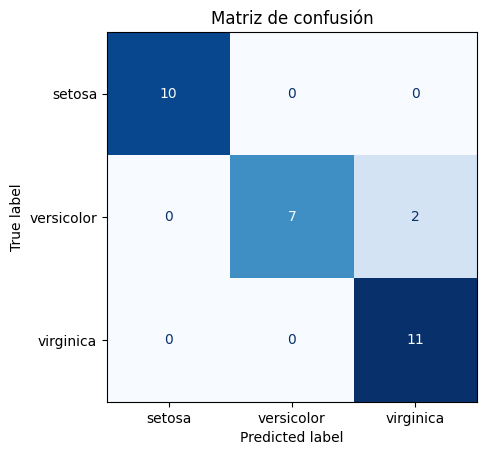

Exactitud: 0.933


In [70]:
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(colorbar=False, cmap='Blues')
plt.title('Matriz de confusión')
plt.show()
ACC = np.mean(Y_pred == Y_test)
print(f"Exactitud: {ACC:.3f}")